In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("vehicles.csv")

print(df.head())
print(df.info())

  Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0        Acura  Integra    Small       12.9   15.9       18.8      25.0   
1          NaN   Legend  Midsize       29.2   33.9       38.7      18.0   
2         Audi       90  Compact       25.9   29.1       32.3      20.0   
3         Audi      100  Midsize        NaN   37.7       44.6      19.0   
4          BMW     535i  Midsize        NaN   30.0        NaN      22.0   

   MPG.highway             AirBags DriveTrain  ... Passengers  Length  \
0         31.0                 NaN      Front  ...        5.0   177.0   
1         25.0  Driver & Passenger      Front  ...        5.0   195.0   
2         26.0         Driver only      Front  ...        5.0   180.0   
3         26.0  Driver & Passenger        NaN  ...        6.0   193.0   
4         30.0                 NaN       Rear  ...        4.0   186.0   

   Wheelbase  Width  Turn.circle Rear.seat.room  Luggage.room  Weight  \
0      102.0   68.0         37.0     

In [3]:
df = df[["Price","EngineSize","Horsepower","Weight"]]

df = df.dropna()

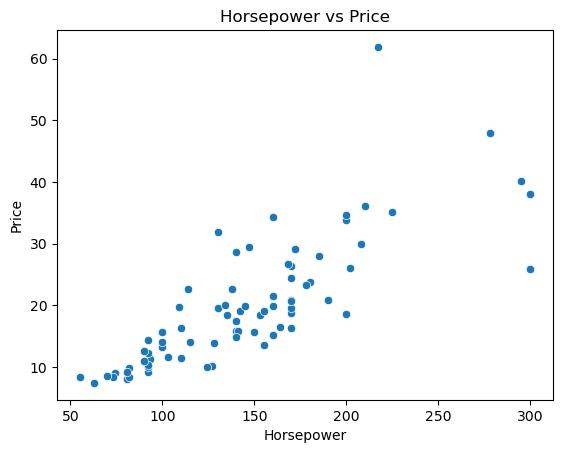

In [4]:
sns.scatterplot(x="Horsepower", y="Price", data=df)

plt.title("Horsepower vs Price")

plt.show()

In [5]:
X = df[["EngineSize","Horsepower","Weight"]]
y = df["Price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [8]:
predictions = model.predict(X_test)

print(predictions[:5])

[24.63581225 11.10625884 22.55622174 17.40409244 23.24554608]


In [11]:
error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 4.854526348323676


In [12]:
import pickle

pickle.dump(model, open("model.pkl","wb"))

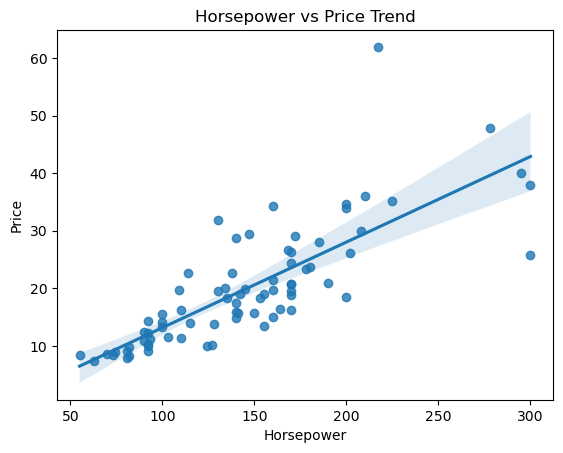

In [13]:
sns.regplot(x="Horsepower", y="Price", data=df)

plt.title("Horsepower vs Price Trend")

plt.show()